# FUSION Overview

Recent advances in spatial-omics technologies enable the study of cellular organization and molecular states within intact tissues at near single-cell resolution, offering unprecedented insight into tissue microenvironments. These approaches have transformed our ability to characterize biological heterogeneity across health and disease.

However, meaningful biological interpretation of spatial-omics data requires integration with tissue morphology and functional tissue units derived from histology. In practice, few existing tools support integrated, interactive analysis of spatial-omics measurements together with high-resolution whole-slide histology, limiting the ability to relate molecular signals to structural context, quantify compartment-specific morphometrics, and compare tissue states across samples and assays.

This gap is particularly restrictive for studies that aim to analyze complex organs or disease processes at scale, where reproducible, compartment-aware analysis is necessary to link molecular profiles with tissue architecture and pathology. Without unified platforms, analyses often rely on fragmented workflows that are difficult to reproduce, extend, or apply consistently across datasets and spatial technologies.

To address these challenges, we present FUSION (Functional Unit State Identification in Whole Slide Images), a web-based platform for integrated visualization and analysis of spatial-omics data with high-resolution histology. FUSION provides workflows for assessing cell composition, extracting quantitative morphometrics, and performing comparative tissue analyses within defined functional tissue units.

FUSION supports multiple spatial assays, including 10x Visium, Visium HD, 10x Xenium, Cell DIVE, and PhenoCycler, and is demonstrated across healthy and diseased tissues from kidney, small intestine, lung, and skin in the Human BioMolecular Atlas Program. Through a series of use cases, we show that FUSION enables the identification of renal glomerular injury states, quantification of morphometric changes, and characterization of fibrosis with associated immune infiltration.

# Initial setup and authentication

In [ ]:
!pip install large_image[all] --find-links https://girder.github.io/large_image_wheels
!jupyter server extension enable jupyter_server_proxy

In [5]:
# Authenticate
user_name='sri15'               # add your user name here 
auth_pass='15110416Sri'         # add your passward here

In [ ]:
import girder_client
gc = girder_client.GirderClient(apiUrl='https://athena.rc.ufl.edu/api/v1')
gc.authenticate(user_name, auth_pass)

# Vizualise HuBMAP data

Download and vizualise hubmap data using hubmapid in the workspace.

In [10]:
from fusion.utilities.visualize import visualize_hubmap_wsi
result = visualize_hubmap_wsi('HBM442.TWQG.458')
result

dataset found for HuBMAP ID HBM442.TWQG.458
uuid:  9bddfb3aab93eadd49e07594bc4678e0
URL: https://assets.hubmapconsortium.org/9bddfb3aab93eadd49e07594bc4678e0/ometiff-pyramids/lab_processed/images/VAN0042-RK-2-75-PAS.ome.tif
VAN0042-RK-2-75-PAS.ome.tif
VAN0042-RK-2-75-PAS.ome.tif already exists. Skipping download.


# Run Jobs (Plugins)

## Segmentation

### multi compartment segmentation

Multi-compartment segmentation is critical for quantitative kidney pathology because accurate histomorphometric analysis depends on the reliable identification and measurement of multiple interacting tissue structures, including glomeruli, tubules, interstitium, and vasculature. Image segmentation is a foundational step in the development of computational pathology and an absolute requirement for automated histomorphometric analysis

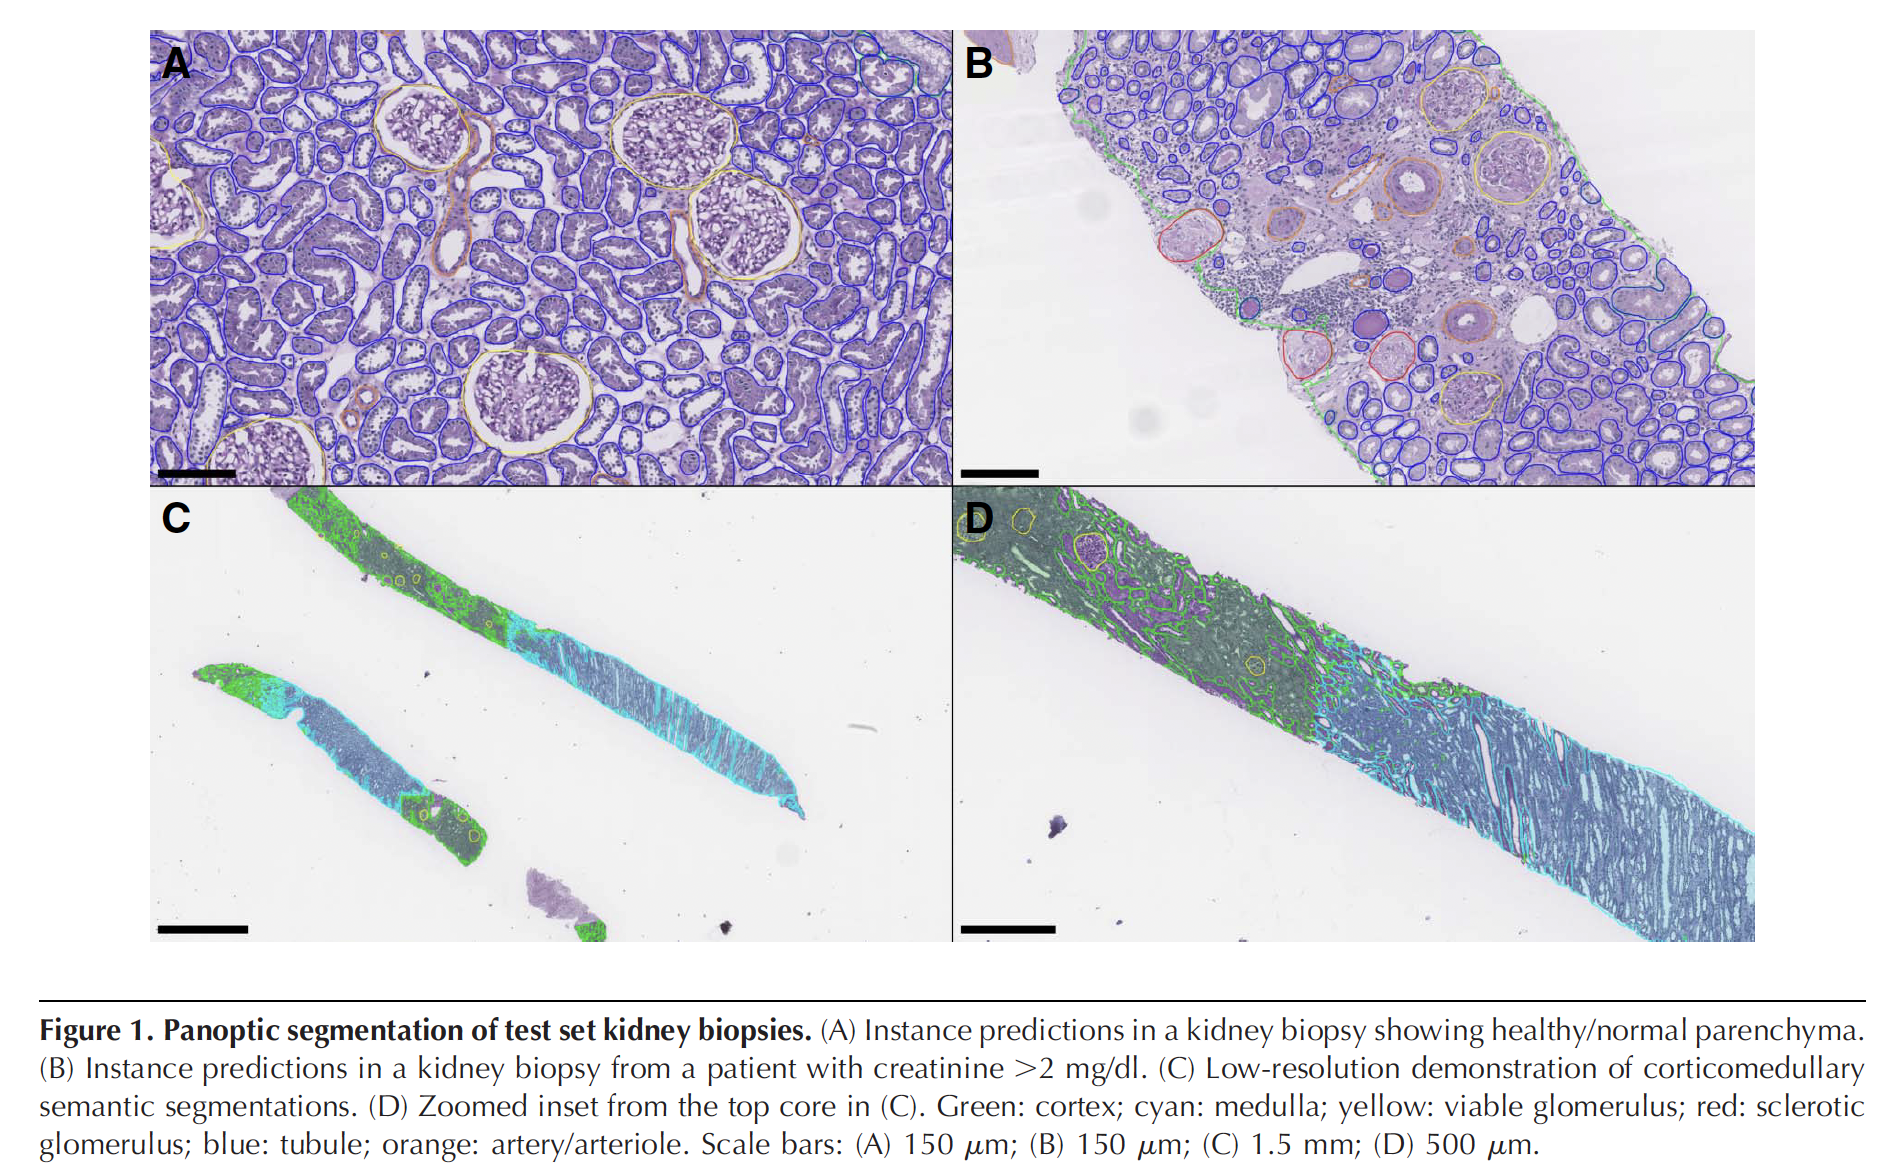

In [ ]:
from fusion import get_multi_compartment_segmentation

hubmapid = 'HBM442.TWQG.458' #change this to whatever dataset id you want to use from hubmap.

res = get_multi_compartment_segmentation(gc,user_name,hubmapid=hubmapid,file_path=None) # You can provide file path instead of hubmapid if the file is in the workspace.

In [ ]:
from fusion import get_job_status

get_job_status(res['job_id'])